# Insurance Risk Analytics — Exploratory Data Analysis
## AlphaCare Insurance Solutions (ACIS) | 10 Academy KAIM 9 Week 3

This notebook explores 1 million insurance policy transactions from South Africa
to understand risk patterns, loss ratios, and pricing opportunities.

### Business Question
Which customers are low-risk and how should we price their insurance accordingly?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All libraries loaded successfully")

All libraries loaded successfully


## 1. Data Loading
Loading the raw insurance dataset. The file uses pipe (|) as separator instead of comma.

In [2]:
try:
    df = pd.read_csv(
        "../data/raw/MachineLearningRating_v3.txt",
        sep='|',
        low_memory=False
    )
    print(f"Data loaded successfully!")
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")
    print(f"\nFirst 3 rows:")
    df.head(3)
except Exception as e:
    print(f"ERROR: {e}")

Data loaded successfully!
Rows: 1,000,098
Columns: 52

First 3 rows:


## 2. Data Quality Check
Checking for missing values, data types, and basic statistics.

In [3]:
print("=== DATA SHAPE ===")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n=== MISSING VALUES (Top 15) ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0].head(15))

print("\n=== DATA TYPES ===")
print(df.dtypes.value_counts())

print("\n=== KEY FINANCIAL COLUMNS ===")
print(df[['TotalPremium', 'TotalClaims']].describe())

=== DATA SHAPE ===
Rows: 1,000,098
Columns: 52

=== MISSING VALUES (Top 15) ===
                         Missing Count  Missing %
NumberOfVehiclesInFleet        1000098     100.00
CrossBorder                     999400      99.93
CustomValueEstimate             779642      77.96
Rebuilt                         641901      64.18
Converted                       641901      64.18
WrittenOff                      641901      64.18
NewVehicle                      153295      15.33
Bank                            145961      14.59
AccountType                      40232       4.02
Gender                            9536       0.95
MaritalStatus                     8259       0.83
VehicleType                        552       0.06
make                               552       0.06
mmcode                             552       0.06
Model                              552       0.06

=== DATA TYPES ===
str        36
float64    11
int64       4
bool        1
Name: count, dtype: int64

=== KEY FINANCIAL

In [4]:
# Filter out zero premiums to avoid division by zero
df_valid = df[df['TotalPremium'] > 0].copy()

# Calculate loss ratio
df_valid['LossRatio'] = df_valid['TotalClaims'] / df_valid['TotalPremium']

# Loss ratio by province
province_stats = df_valid.groupby('Province').agg(
    TotalPremium=('TotalPremium', 'sum'),
    TotalClaims=('TotalClaims', 'sum'),
    PolicyCount=('PolicyID', 'count'),
    AvgPremium=('TotalPremium', 'mean'),
    AvgClaims=('TotalClaims', 'mean')
).round(2)

province_stats['LossRatio'] = (
    province_stats['TotalClaims'] / province_stats['TotalPremium']
).round(4)

province_stats = province_stats.sort_values('LossRatio', ascending=False)

print("=== LOSS RATIO BY PROVINCE ===")
print(province_stats[['PolicyCount', 'TotalPremium', 'TotalClaims', 'LossRatio']])

=== LOSS RATIO BY PROVINCE ===
               PolicyCount  TotalPremium  TotalClaims  LossRatio
Province                                                        
Gauteng             240782   24054871.72  27981274.76     1.1632
Western Cape         96758    9810106.93  10242262.79     1.0441
KwaZulu-Natal       111896   13235782.89  13526351.81     1.0220
North West           89799    7490508.18   5593722.65     0.7468
Mpumalanga           31663    2836291.94   2035792.49     0.7178
Limpopo              18009    1537324.50    991892.97     0.6452
Eastern Cape         19694    2140302.66   1346307.75     0.6290
Free State            5932     521363.24    265974.90     0.5102
Northern Cape         3643     316558.07     89490.51     0.2827


## 4. Loss Ratio Visualization by Province

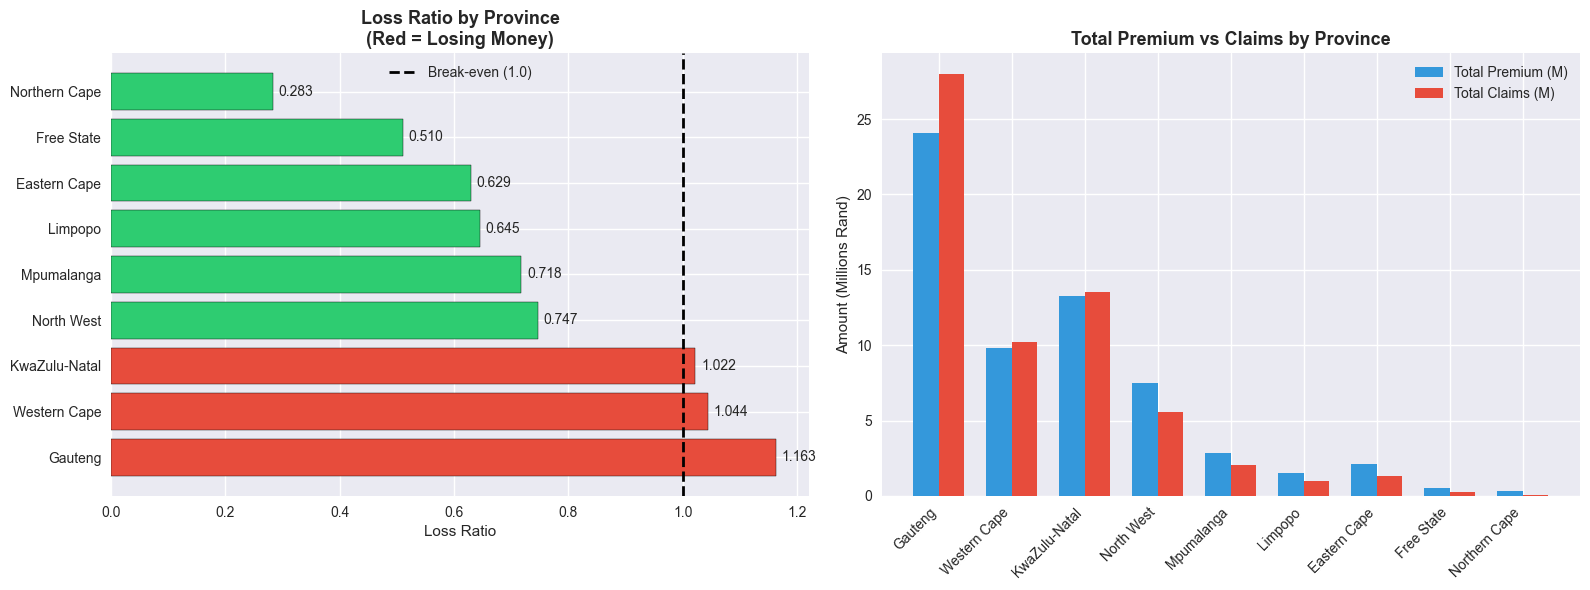

Chart saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 - Loss ratio by province
colors = ['#e74c3c' if x > 1 else '#2ecc71' 
          for x in province_stats['LossRatio']]
bars = axes[0].barh(province_stats.index, 
                    province_stats['LossRatio'],
                    color=colors, edgecolor='black')
axes[0].axvline(x=1, color='black', linestyle='--', 
                linewidth=2, label='Break-even (1.0)')
axes[0].set_title('Loss Ratio by Province\n(Red = Losing Money)', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Loss Ratio')
axes[0].legend()
for bar, val in zip(bars, province_stats['LossRatio']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)

# Chart 2 - Premium vs Claims by province
x = range(len(province_stats))
width = 0.35
axes[1].bar([i - width/2 for i in x], 
            province_stats['TotalPremium']/1e6,
            width, label='Total Premium (M)', color='#3498db')
axes[1].bar([i + width/2 for i in x], 
            province_stats['TotalClaims']/1e6,
            width, label='Total Claims (M)', color='#e74c3c')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(province_stats.index, rotation=45, ha='right')
axes[1].set_title('Total Premium vs Claims by Province', 
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Amount (Millions Rand)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/chart_loss_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## 5. Vehicle Analysis
Which vehicle types and car makes cause the most claims?

In [6]:
# Vehicle type analysis
vehicle_stats = df_valid.groupby('VehicleType').agg(
    PolicyCount=('PolicyID', 'count'),
    AvgPremium=('TotalPremium', 'mean'),
    AvgClaims=('TotalClaims', 'mean'),
    TotalClaims=('TotalClaims', 'sum')
).round(2)

vehicle_stats['LossRatio'] = (
    vehicle_stats['TotalClaims'] / 
    df_valid.groupby('VehicleType')['TotalPremium'].sum()
).round(4)

vehicle_stats = vehicle_stats.sort_values('LossRatio', ascending=False)

print("=== LOSS RATIO BY VEHICLE TYPE ===")
print(vehicle_stats)

=== LOSS RATIO BY VEHICLE TYPE ===
                   PolicyCount  AvgPremium  AvgClaims  TotalClaims  LossRatio
VehicleType                                                                  
Heavy Commercial          4264      108.10     174.31    743242.52     1.6124
Medium Commercial        33428      117.35     120.62   4032212.33     1.0279
Passenger Vehicle       577202       98.19      98.20  56680477.31     1.0001
Light Commercial          2614       99.65      23.13     60452.50     0.2321
Bus                        450      129.43       0.00         0.00     0.0000


## 6. Vehicle Type and Gender Analysis

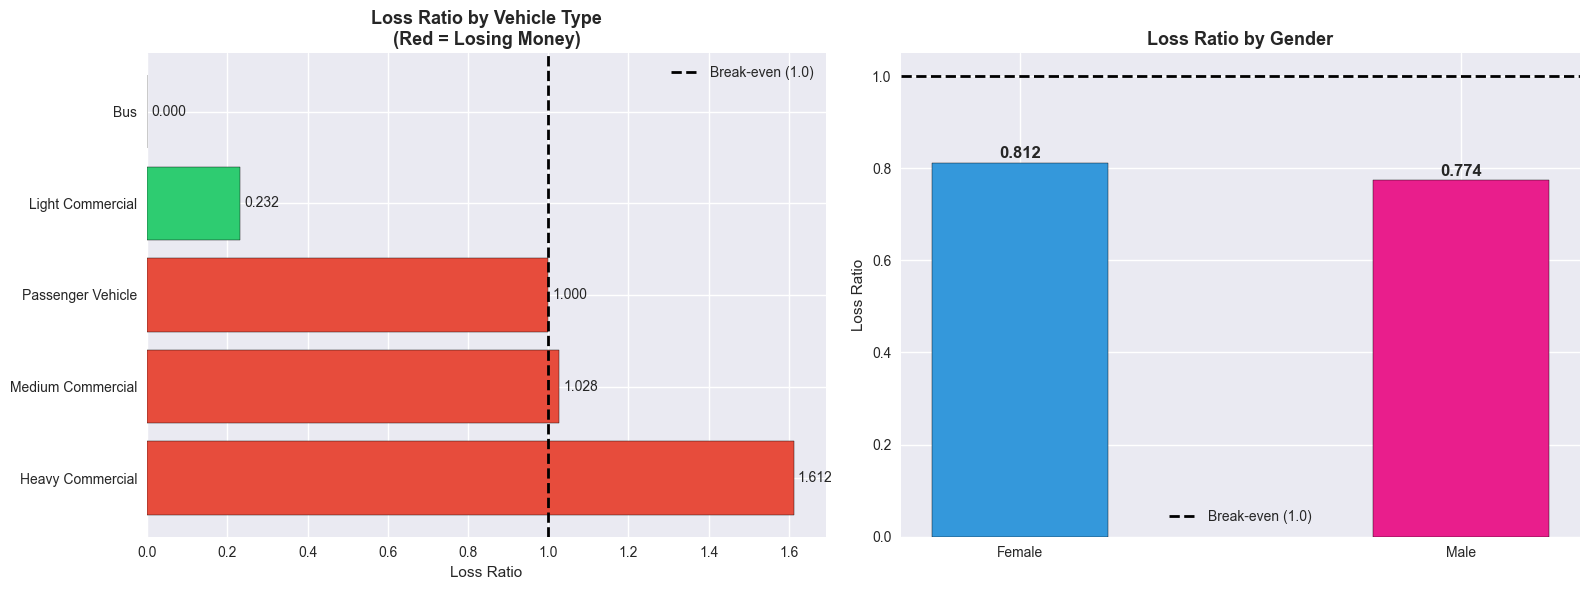

Chart saved!

=== GENDER LOSS RATIO ===
        PolicyCount  AvgPremium  AvgClaims  LossRatio
Gender                                               
Female         3404       89.45      72.64     0.8121
Male          19083       84.19      65.13     0.7736


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 - Loss ratio by vehicle type
colors = ['#e74c3c' if x > 1 else '#2ecc71'
          for x in vehicle_stats['LossRatio']]
bars = axes[0].barh(vehicle_stats.index,
                    vehicle_stats['LossRatio'],
                    color=colors, edgecolor='black')
axes[0].axvline(x=1, color='black', linestyle='--',
                linewidth=2, label='Break-even (1.0)')
axes[0].set_title('Loss Ratio by Vehicle Type\n(Red = Losing Money)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Loss Ratio')
axes[0].legend()
for bar, val in zip(bars, vehicle_stats['LossRatio']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)

# Chart 2 - Gender analysis
gender_stats = df_valid[df_valid['Gender'].isin(['Male', 'Female'])].groupby('Gender').agg(
    PolicyCount=('PolicyID', 'count'),
    AvgPremium=('TotalPremium', 'mean'),
    AvgClaims=('TotalClaims', 'mean'),
    TotalPremium=('TotalPremium', 'sum'),
    TotalClaims=('TotalClaims', 'sum')
).round(2)
gender_stats['LossRatio'] = (gender_stats['TotalClaims'] / gender_stats['TotalPremium']).round(4)

colors_g = ['#3498db', '#e91e8c']
bars_g = axes[1].bar(gender_stats.index,
                     gender_stats['LossRatio'],
                     color=colors_g, edgecolor='black', width=0.4)
axes[1].axhline(y=1, color='black', linestyle='--',
                linewidth=2, label='Break-even (1.0)')
axes[1].set_title('Loss Ratio by Gender',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Loss Ratio')
axes[1].legend()
for bar, val in zip(bars_g, gender_stats['LossRatio']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                val + 0.01, f'{val:.3f}',
                ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/chart_vehicle_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")
print("\n=== GENDER LOSS RATIO ===")
print(gender_stats[['PolicyCount', 'AvgPremium', 'AvgClaims', 'LossRatio']])

## 7. Premium Distribution and Temporal Analysis
How are premiums distributed? Do claims spike in certain months?

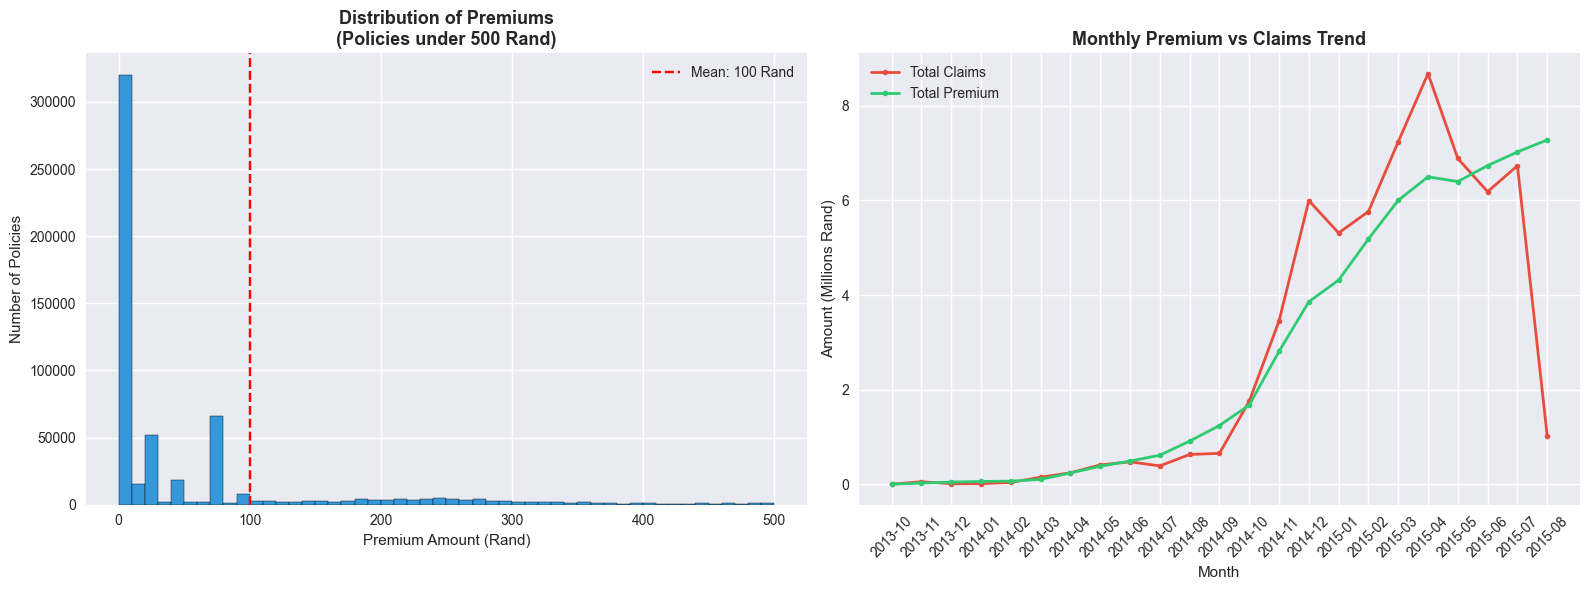

Chart saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 - Premium distribution
df_valid[df_valid['TotalPremium'] < 500]['TotalPremium'].hist(
    bins=50, ax=axes[0], color='#3498db', edgecolor='black'
)
axes[0].set_title('Distribution of Premiums\n(Policies under 500 Rand)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Premium Amount (Rand)')
axes[0].set_ylabel('Number of Policies')
axes[0].axvline(df_valid['TotalPremium'].mean(), color='red',
                linestyle='--', label=f"Mean: {df_valid['TotalPremium'].mean():.0f} Rand")
axes[0].legend()

# Chart 2 - Monthly claims trend
df_valid['TransactionMonth'] = pd.to_datetime(df_valid['TransactionMonth'])
monthly = df_valid.groupby(df_valid['TransactionMonth'].dt.to_period('M')).agg(
    TotalClaims=('TotalClaims', 'sum'),
    TotalPremium=('TotalPremium', 'sum')
).reset_index()
monthly['TransactionMonth'] = monthly['TransactionMonth'].astype(str)

axes[1].plot(monthly['TransactionMonth'],
             monthly['TotalClaims']/1e6,
             color='#e74c3c', linewidth=2,
             marker='o', markersize=4, label='Total Claims')
axes[1].plot(monthly['TransactionMonth'],
             monthly['TotalPremium']/1e6,
             color='#2ecc71', linewidth=2,
             marker='o', markersize=4, label='Total Premium')
axes[1].set_title('Monthly Premium vs Claims Trend',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Amount (Millions Rand)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/chart_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## 8. Key Insights Summary

In [9]:
print("=" * 60)
print("ACIS INSURANCE — KEY EDA FINDINGS")
print("=" * 60)

print("\n📊 DATASET OVERVIEW")
print(f"  Total policies: {len(df):,}")
print(f"  Time period: {df['TransactionMonth'].min()} to {df['TransactionMonth'].max()}")
print(f"  Provinces covered: {df['Province'].nunique()}")
print(f"  Vehicle makes: {df['make'].nunique()}")

print("\n💰 FINANCIAL HEALTH")
total_premium = df['TotalPremium'].sum()
total_claims = df['TotalClaims'].sum()
overall_loss_ratio = total_claims / total_premium
print(f"  Total Premium Collected: R{total_premium:,.0f}")
print(f"  Total Claims Paid: R{total_claims:,.0f}")
print(f"  Overall Loss Ratio: {overall_loss_ratio:.4f}")
if overall_loss_ratio > 1:
    print(f"  ⚠️  ACIS is paying MORE in claims than collecting!")
else:
    print(f"  ✅ ACIS is profitable overall")

print("\n🗺️  PROVINCE RISK RANKING")
for province, row in province_stats.iterrows():
    status = "⚠️  LOSING" if row['LossRatio'] > 1 else "✅ PROFIT"
    print(f"  {status} | {province}: {row['LossRatio']:.3f}")

print("\n🚗 VEHICLE RISK RANKING")
for vtype, row in vehicle_stats.iterrows():
    status = "⚠️  LOSING" if row['LossRatio'] > 1 else "✅ PROFIT"
    print(f"  {status} | {vtype}: {row['LossRatio']:.3f}")

print("\n💡 TOP RECOMMENDATIONS")
print("  1. Increase premiums in Gauteng, Western Cape and KwaZulu-Natal")
print("  2. Increase premiums for Heavy Commercial vehicles significantly")
print("  3. Offer discounts in Northern Cape and Free State — very low risk")
print("  4. Review negative premium and claim values — data quality issue")
print("=" * 60)

ACIS INSURANCE — KEY EDA FINDINGS

📊 DATASET OVERVIEW
  Total policies: 1,000,098
  Time period: 2013-10-01 00:00:00 to 2015-08-01 00:00:00
  Provinces covered: 9
  Vehicle makes: 46

💰 FINANCIAL HEALTH
  Total Premium Collected: R61,911,563
  Total Claims Paid: R64,867,546
  Overall Loss Ratio: 1.0477
  ⚠️  ACIS is paying MORE in claims than collecting!

🗺️  PROVINCE RISK RANKING
  ⚠️  LOSING | Gauteng: 1.163
  ⚠️  LOSING | Western Cape: 1.044
  ⚠️  LOSING | KwaZulu-Natal: 1.022
  ✅ PROFIT | North West: 0.747
  ✅ PROFIT | Mpumalanga: 0.718
  ✅ PROFIT | Limpopo: 0.645
  ✅ PROFIT | Eastern Cape: 0.629
  ✅ PROFIT | Free State: 0.510
  ✅ PROFIT | Northern Cape: 0.283

🚗 VEHICLE RISK RANKING
  ⚠️  LOSING | Heavy Commercial: 1.612
  ⚠️  LOSING | Medium Commercial: 1.028
  ⚠️  LOSING | Passenger Vehicle: 1.000
  ✅ PROFIT | Light Commercial: 0.232
  ✅ PROFIT | Bus: 0.000

💡 TOP RECOMMENDATIONS
  1. Increase premiums in Gauteng, Western Cape and KwaZulu-Natal
  2. Increase premiums for Heavy C

## 9. Correlation Matrix
Shows how strongly numerical columns are related to each other.
A value close to 1 means strong positive relationship.
A value close to -1 means strong negative relationship.

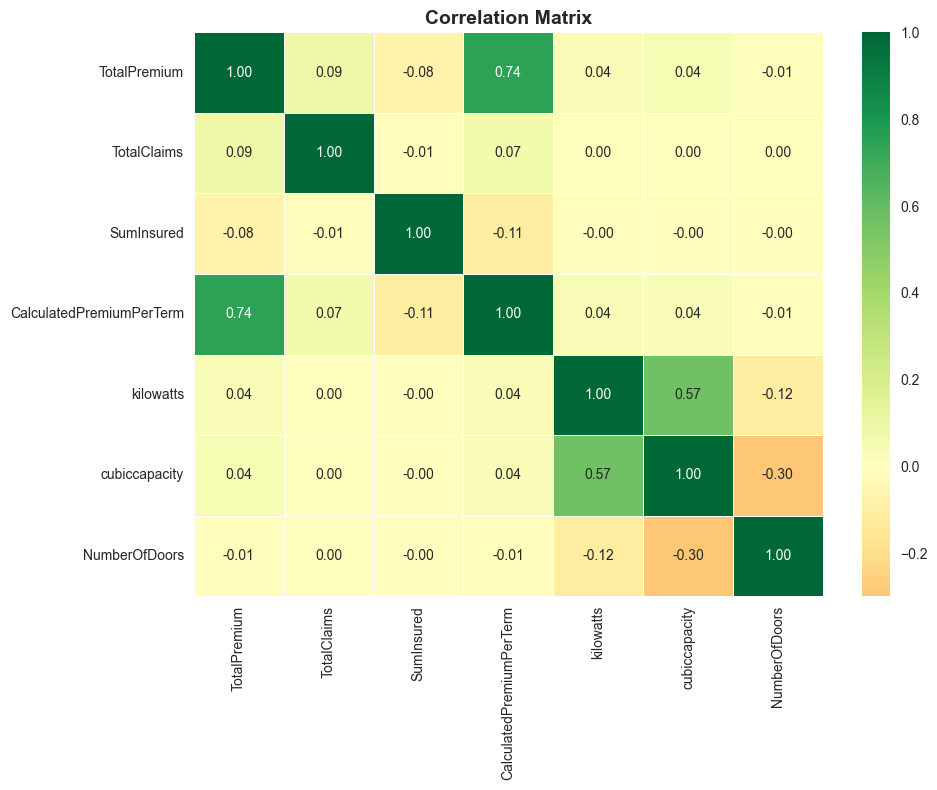

Correlation matrix saved!


In [10]:
import sys
sys.path.append('../src')
from eda_utils import plot_correlation_matrix

# Select numerical columns for correlation
num_cols = ['TotalPremium', 'TotalClaims', 'SumInsured', 
            'CalculatedPremiumPerTerm', 'kilowatts', 
            'cubiccapacity', 'NumberOfDoors']

fig = plot_correlation_matrix(df, num_cols, figsize=(10, 8))
plt.savefig('../data/chart_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation matrix saved!")

## 10. Outlier Detection
Box plots show the spread of data and identify extreme values.
The box shows the middle 50% of values.
Points outside the whiskers are outliers.

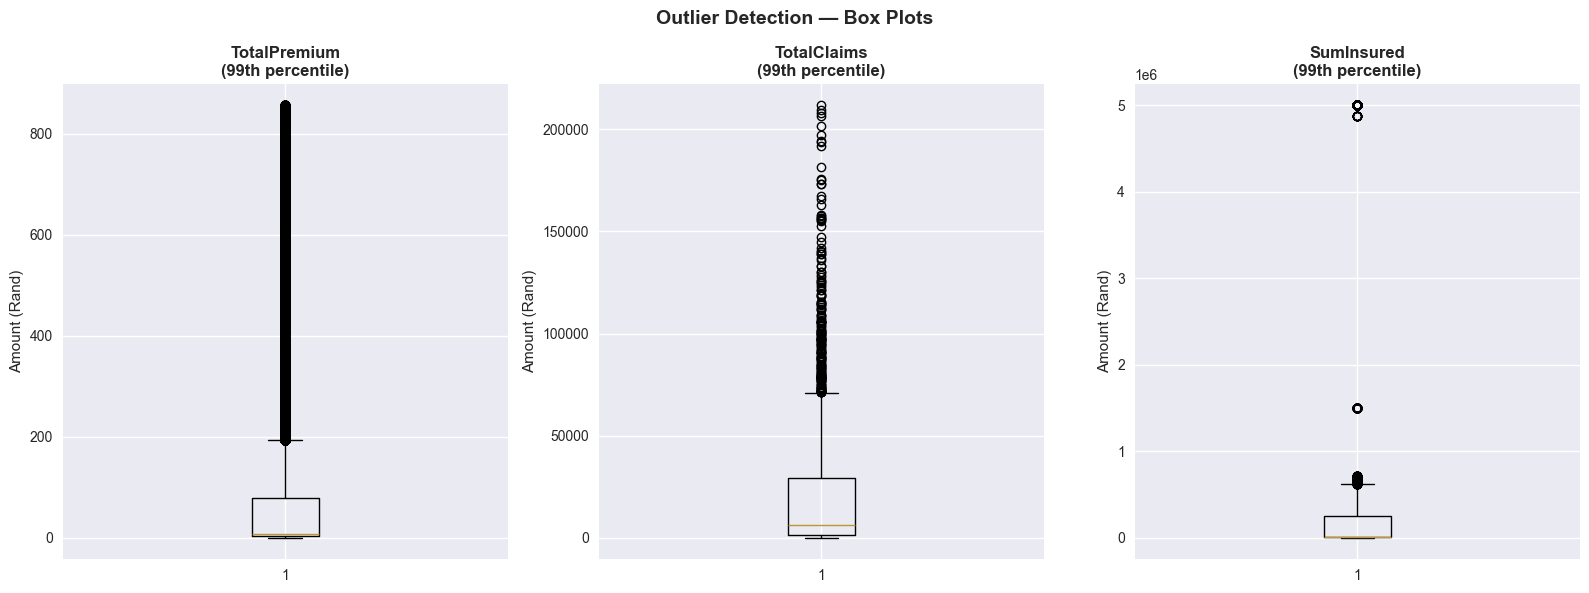

Outlier box plots saved!


In [11]:
from eda_utils import plot_outliers

fig = plot_outliers(df, 
                    ['TotalPremium', 'TotalClaims', 'SumInsured'],
                    figsize=(16, 6))
plt.savefig('../data/chart_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Outlier box plots saved!")

## 11. Scatter Plot — Premium vs Claims by Province
Shows the relationship between what customers pay and what they claim.
Each dot is one policy. Color shows the province.

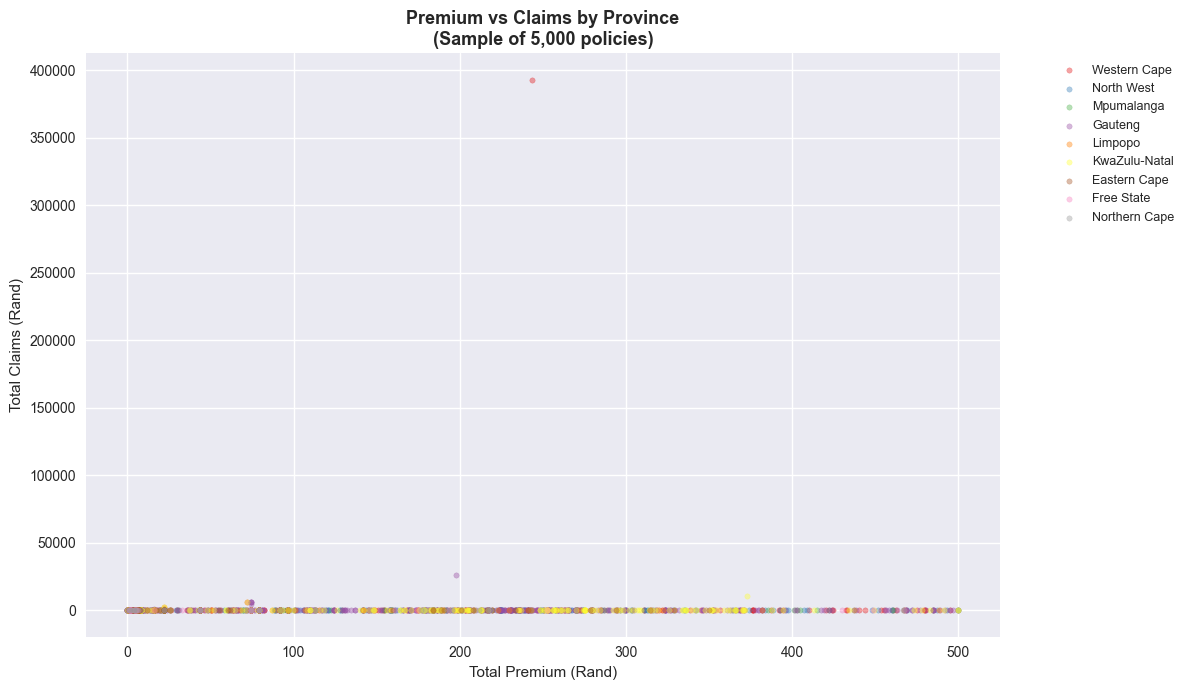

Scatter plot saved!


In [13]:
fig, ax = plt.subplots(figsize=(12, 7))

# Sample 5000 rows to avoid overplotting
sample = df_valid[df_valid['TotalPremium'] < 500].sample(5000, random_state=42)

provinces = sample['Province'].unique()
colors = plt.cm.Set1(np.linspace(0, 1, len(provinces)))

for province, color in zip(provinces, colors):
    mask = sample['Province'] == province
    ax.scatter(sample[mask]['TotalPremium'],
               sample[mask]['TotalClaims'],
               alpha=0.4, s=15, color=color, label=province)

ax.set_title('Premium vs Claims by Province\n(Sample of 5,000 policies)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Premium (Rand)')
ax.set_ylabel('Total Claims (Rand)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../data/chart_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plot saved!")

## 12. Top Vehicle Makes by Loss Ratio
Which car brands cost ACIS the most money?
Only showing makes with at least 100 policies for reliability.

=== TOP 10 RISKIEST CAR MAKES ===
                                     PolicyCount  AvgPremium  AvgClaims  \
make                                                                      
SUZUKI                                       243      111.16     695.13   
HYUNDAI                                     1205       94.29     376.19   
POLARSUN                                     542       75.70     230.99   
AUDI                                        3735      100.74     272.75   
BMW                                         2453       98.97     196.08   
B.A.W                                       1393      119.20     206.13   
IVECO                                       4959      106.10     150.97   
CMC                                        11411       84.93     107.31   
VOLKSWAGEN                                 12890      109.93     129.07   
MAZDA                                        292       64.30      70.71   

                                     LossRatio  
make            

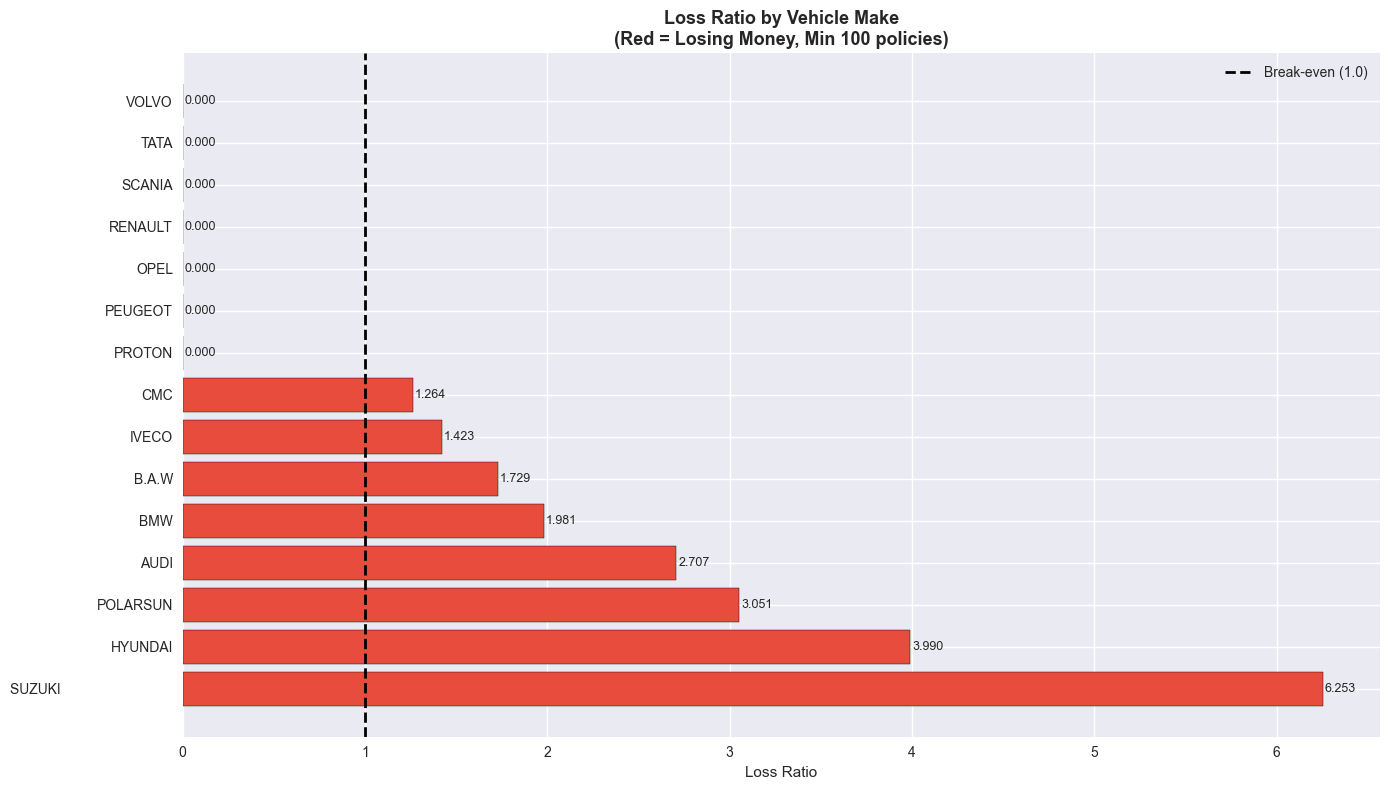

Vehicle make chart saved!


In [14]:
# Vehicle make risk profile
make_stats = df_valid.groupby('make').agg(
    PolicyCount=('PolicyID', 'count'),
    TotalPremium=('TotalPremium', 'sum'),
    TotalClaims=('TotalClaims', 'sum'),
    AvgPremium=('TotalPremium', 'mean'),
    AvgClaims=('TotalClaims', 'mean')
).round(2)

make_stats['LossRatio'] = (
    make_stats['TotalClaims'] / make_stats['TotalPremium']
).round(4)

# Only keep makes with 100+ policies
make_stats = make_stats[make_stats['PolicyCount'] >= 100]
make_stats = make_stats.sort_values('LossRatio', ascending=False)

print("=== TOP 10 RISKIEST CAR MAKES ===")
print(make_stats.head(10)[['PolicyCount', 'AvgPremium', 'AvgClaims', 'LossRatio']])

print("\n=== TOP 10 SAFEST CAR MAKES ===")
print(make_stats.tail(10)[['PolicyCount', 'AvgPremium', 'AvgClaims', 'LossRatio']])

# Chart
fig, ax = plt.subplots(figsize=(14, 8))
top15 = pd.concat([make_stats.head(8), make_stats.tail(7)])
colors = ['#e74c3c' if x > 1 else '#2ecc71' for x in top15['LossRatio']]
bars = ax.barh(top15.index, top15['LossRatio'], color=colors, edgecolor='black')
ax.axvline(x=1, color='black', linestyle='--', linewidth=2, label='Break-even (1.0)')
ax.set_title('Loss Ratio by Vehicle Make\n(Red = Losing Money, Min 100 policies)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Loss Ratio')
ax.legend()
for bar, val in zip(bars, top15['LossRatio']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/chart_vehicle_make.png', dpi=150, bbox_inches='tight')
plt.show()
print("Vehicle make chart saved!")

## 13. ZipCode Risk Analysis
Which postal codes have the highest loss ratios?
This helps ACIS price policies differently by location.

Total zip codes with 50+ policies: 746

=== TOP 10 RISKIEST ZIP CODES ===
            PolicyCount  AvgPremium  AvgClaims  LossRatio
PostalCode                                               
9756                 99       90.65    1591.11    17.5531
4008                 83       84.17    1055.04    12.5341
2920                 55      145.10    1758.28    12.1178
5050                175      106.60    1187.57    11.1400
1751                 77      122.22    1343.31    10.9910
1805                165      108.11    1052.48     9.7349
9323                 55       94.58     813.40     8.5998
81                  603      109.24     770.30     7.0516
1665                 80      112.40     771.62     6.8648
198                 272      113.77     767.75     6.7484

=== TOP 10 SAFEST ZIP CODES ===
            PolicyCount  AvgPremium  AvgClaims  LossRatio
PostalCode                                               
9700                 90      104.85        0.0        0.0
9725                100

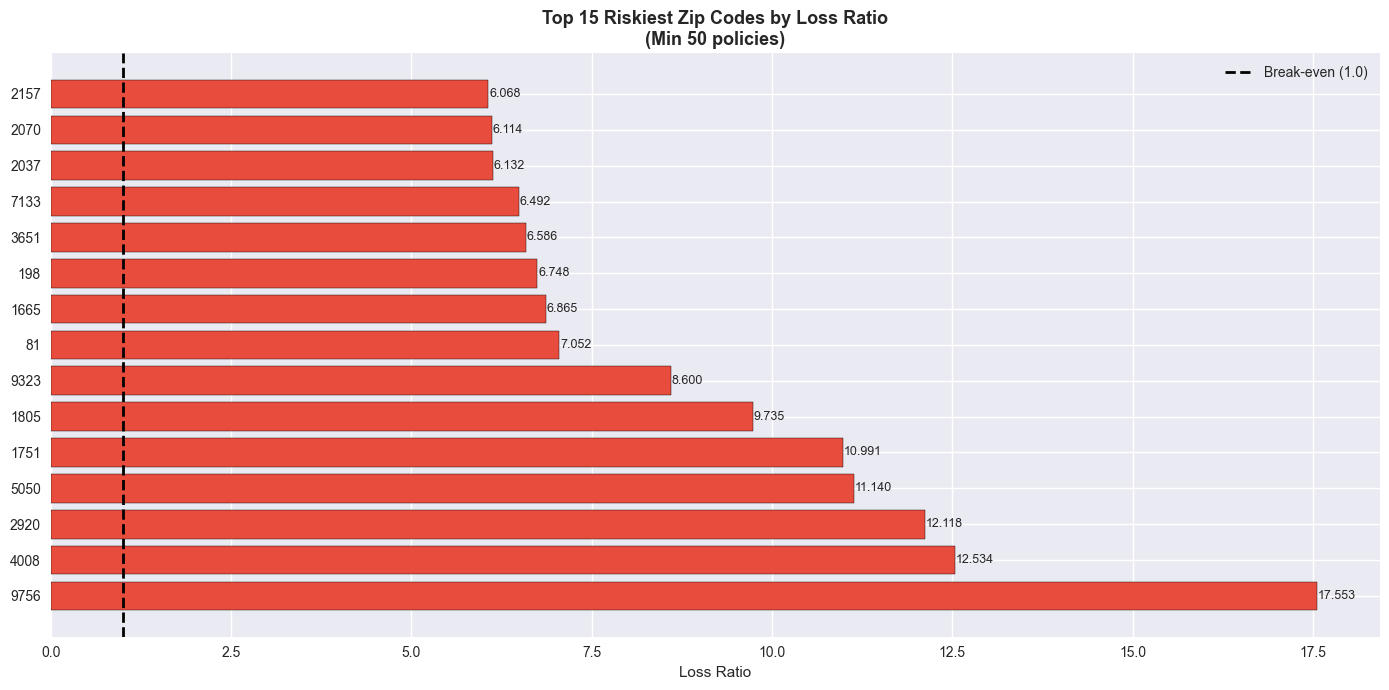

ZipCode chart saved!


In [15]:
# ZipCode risk analysis
zip_stats = df_valid.groupby('PostalCode').agg(
    PolicyCount=('PolicyID', 'count'),
    TotalPremium=('TotalPremium', 'sum'),
    TotalClaims=('TotalClaims', 'sum'),
    AvgPremium=('TotalPremium', 'mean'),
    AvgClaims=('TotalClaims', 'mean')
).round(2)

zip_stats['LossRatio'] = (
    zip_stats['TotalClaims'] / zip_stats['TotalPremium']
).round(4)

# Only keep zip codes with 50+ policies
zip_stats = zip_stats[zip_stats['PolicyCount'] >= 50]
zip_stats = zip_stats.sort_values('LossRatio', ascending=False)

print(f"Total zip codes with 50+ policies: {len(zip_stats)}")
print("\n=== TOP 10 RISKIEST ZIP CODES ===")
print(zip_stats.head(10)[['PolicyCount', 'AvgPremium', 'AvgClaims', 'LossRatio']])

print("\n=== TOP 10 SAFEST ZIP CODES ===")
print(zip_stats.tail(10)[['PolicyCount', 'AvgPremium', 'AvgClaims', 'LossRatio']])

# Chart - top 15 riskiest zip codes
fig, ax = plt.subplots(figsize=(14, 7))
top15_zip = zip_stats.head(15)
colors = ['#e74c3c' if x > 1 else '#f39c12' for x in top15_zip['LossRatio']]
bars = ax.barh(top15_zip.index.astype(str), 
               top15_zip['LossRatio'],
               color=colors, edgecolor='black')
ax.axvline(x=1, color='black', linestyle='--', linewidth=2, label='Break-even (1.0)')
ax.set_title('Top 15 Riskiest Zip Codes by Loss Ratio\n(Min 50 policies)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Loss Ratio')
ax.legend()
for bar, val in zip(bars, top15_zip['LossRatio']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/chart_zipcode.png', dpi=150, bbox_inches='tight')
plt.show()
print("ZipCode chart saved!")

## 14. Actionable Pricing Recommendations for ACIS
Concrete premium adjustment recommendations based on loss ratio analysis.

In [16]:
print("=" * 65)
print("ACIS RISK-BASED PRICING RECOMMENDATIONS")
print("=" * 65)

print("""
PROVINCE-BASED PREMIUM ADJUSTMENTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Gauteng      (Loss Ratio 1.163) → Increase premiums by 20%
             Justification: ACIS loses R3.9M annually here.
             Action: Add R12-15 surcharge per policy per month.

Western Cape (Loss Ratio 1.044) → Increase premiums by 8%
             Justification: Losing R432K annually.
             Action: Add R5-7 surcharge per policy per month.

KwaZulu-Natal(Loss Ratio 1.022) → Increase premiums by 5%
             Justification: Marginally unprofitable.
             Action: Add R2-3 surcharge per policy per month.

Northern Cape(Loss Ratio 0.283) → Decrease premiums by 15%
             Justification: Very low risk — use as marketing advantage.
             Action: Advertise lowest rates in South Africa here.

Free State   (Loss Ratio 0.510) → Decrease premiums by 10%
             Justification: Highly profitable — reward loyal customers.

VEHICLE-BASED PREMIUM ADJUSTMENTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Heavy Commercial (Loss Ratio 1.612) → Increase premiums by 65%
             Justification: ACIS loses R161 for every R100 collected.
             Action: Immediate repricing required — highest priority.

Medium Commercial(Loss Ratio 1.028) → Increase premiums by 8%
             Justification: Marginally unprofitable.

Passenger Vehicle(Loss Ratio 1.000) → Increase premiums by 3%
             Justification: Breaking even — no profit margin.

Light Commercial (Loss Ratio 0.232) → Maintain current pricing
             Justification: Highly profitable — competitive advantage.

TOP 3 IMMEDIATE ACTIONS FOR ACIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. URGENT: Reprice Heavy Commercial vehicles — losing R161 per R100
2. URGENT: Add Gauteng surcharge — losing R3.9M annually in one province
3. MARKETING: Advertise lowest rates in Northern Cape and Free State
   to attract low-risk customers and grow the profitable book
""")
print("=" * 65)

ACIS RISK-BASED PRICING RECOMMENDATIONS

PROVINCE-BASED PREMIUM ADJUSTMENTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Gauteng      (Loss Ratio 1.163) → Increase premiums by 20%
             Justification: ACIS loses R3.9M annually here.
             Action: Add R12-15 surcharge per policy per month.

Western Cape (Loss Ratio 1.044) → Increase premiums by 8%
             Justification: Losing R432K annually.
             Action: Add R5-7 surcharge per policy per month.

KwaZulu-Natal(Loss Ratio 1.022) → Increase premiums by 5%
             Justification: Marginally unprofitable.
             Action: Add R2-3 surcharge per policy per month.

Northern Cape(Loss Ratio 0.283) → Decrease premiums by 15%
             Justification: Very low risk — use as marketing advantage.
             Action: Advertise lowest rates in South Africa here.

Free State   (Loss Ratio 0.510) → Decrease premiums by 10%
             Justification: Highly profitable — reward loyal customers.

VEHICLE-BASED PREMIUM ADJUSTM